# Linear regression only: materials + made-in country

Upload the Mango and Zara CSVs when prompted, then run all cells top to bottom.

In [10]:
!pip -q install pandas numpy scikit-learn matplotlib

In [17]:

# ============================================================
# Colab script: Linear regression using ONLY materials + made_in
# Compares US vs India prices for Mango and Zara
# ============================================================

import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams["figure.dpi"] = 140
pd.set_option("display.max_columns", 200)

# -----------------------------
# 1) Upload files
# -----------------------------
uploaded = files.upload()

def find_file(name_parts):
    for fname in uploaded.keys():
        lower = fname.lower()
        if all(part in lower for part in name_parts):
            return fname
    return None

mango_file = find_file(["mango"]) or find_file(["comparison"])
zara_file = find_file(["zara"])

if mango_file is None or zara_file is None:
    raise ValueError("Please upload both the Mango CSV and the Zara CSV.")

mango = pd.read_csv(io.BytesIO(uploaded[mango_file])).copy()
zara = pd.read_csv(io.BytesIO(uploaded[zara_file])).copy()

mango["Brand"] = "Mango"
zara["Brand"] = "Zara"

# -----------------------------
# 2) Keep ONLY what we need
# -----------------------------
def keep_only_needed(df, brand):
    out = df.copy()

    # exact price column names differ slightly across files, but these are the ones present
    keep_cols = ["Brand", "materials_text", "made_in", "US_price_current_usd", "IN_price_current_usd"]
    for col in keep_cols:
        if col not in out.columns:
            out[col] = np.nan

    out = out[keep_cols].copy()
    out["Brand"] = brand
    return out

mango = keep_only_needed(mango, "Mango")
zara = keep_only_needed(zara, "Zara")

df = pd.concat([mango, zara], ignore_index=True)

# -----------------------------
# 3) Clean made_in
# -----------------------------
country_words = [
    "Bangladesh", "China", "Morocco", "Turkey", "Cambodia", "Portugal",
    "Vietnam", "India", "Pakistan", "Egypt", "Spain", "Laos", "Myanmar",
    "Indonesia", "Sri Lanka", "Tunisia", "Italy"
]

def clean_made_in(x):
    if pd.isna(x):
        return np.nan
    s = str(x).replace("\n", " ").strip()
    for c in country_words:
        if re.search(rf"\b{re.escape(c)}\b", s, flags=re.I):
            return c
    # fallback: first chunk before extra text
    first = s.split("|")[0].strip()
    first = re.sub(r"\s+", " ", first)
    return first if first else np.nan

df["made_in_clean"] = df["made_in"].apply(clean_made_in)

# -----------------------------
# 4) Parse materials_text into numeric features
#    Uses ONLY exact materials text from your files
# -----------------------------
material_map = {
    "cotton": ["cotton", "organically grown cotton", "recycled cotton"],
    "polyester": ["polyester", "recycled polyester"],
    "linen": ["linen", "european grown linen", "recycled linen"],
    "elastane": ["elastane"],
    "viscose": ["viscose"],
    "wool": ["wool", "merino wool", "recycled wool", "certified wool"],
    "polyamide": ["polyamide"],
    "lyocell": ["lyocell"],
    "modal": ["modal"],
    "acrylic": ["acrylic"],
    "silk": ["silk"],
    "cashmere": ["cashmere"],
    "leather": ["leather", "suede"],
    "other_fibres": ["other fibres", "other fibers"],
}

material_cols = list(material_map.keys())

def extract_material_shares(text):
    shares = {m: 0.0 for m in material_cols}
    if pd.isna(text):
        return shares

    s = str(text).lower()

    # percentage-based extraction
    matches = re.findall(r'(\d+(?:\.\d+)?)%\s*([a-z][a-z\s\-]+?)(?=,|\||$)', s)
    total = 0.0
    for pct_str, raw_mat in matches:
        pct = float(pct_str)
        raw_mat = raw_mat.strip()
        matched = False
        for canonical, variants in material_map.items():
            if any(v in raw_mat for v in variants):
                shares[canonical] += pct
                total += pct
                matched = True
                break

    # fallback: if no percentages found, use binary mentions
    if total == 0:
        binary_hits = 0
        for canonical, variants in material_map.items():
            if any(v in s for v in variants):
                shares[canonical] = 1.0
                binary_hits += 1
        total = float(binary_hits)

    # normalize so rows are comparable
    if total > 0:
        shares = {k: v / total for k, v in shares.items()}

    return shares

material_features = pd.DataFrame(df["materials_text"].apply(extract_material_shares).tolist())
df = pd.concat([df, material_features], axis=1)

df["dominant_material"] = material_features.idxmax(axis=1)
row_sums = material_features.sum(axis=1)
df.loc[row_sums == 0, "dominant_material"] = "unknown"

# -----------------------------
# 5) Helper: fit linear regression for one brand + one market
# -----------------------------
def fit_one_model(data, brand, target_col):
    sub = data.loc[
        (data["Brand"] == brand)
        & data["materials_text"].notna()
        & data["made_in_clean"].notna()
        & data[target_col].notna()
    ].copy()

    # drop tiny country groups into Other to avoid unstable coefficients
    country_counts = sub["made_in_clean"].value_counts()
    keep_countries = country_counts[country_counts >= 3].index
    sub["made_in_model"] = np.where(sub["made_in_clean"].isin(keep_countries), sub["made_in_clean"], "Other")

    feature_cols_num = material_cols
    feature_cols_cat = ["made_in_model"]

    X = sub[feature_cols_num + feature_cols_cat].copy()
    y = sub[target_col].astype(float).copy()

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
                ("scaler", StandardScaler())
            ]), feature_cols_num),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), feature_cols_cat),
        ]
    )

    model = Pipeline([
        ("pre", pre),
        ("lr", LinearRegression())
    ])

    model.fit(X, y)
    preds = model.predict(X)

    results = sub.copy()
    results["target_price"] = y.values
    results["predicted_price"] = preds
    results["residual"] = results["target_price"] - results["predicted_price"]
    results["market"] = "USA" if "US_" in target_col else "India"

    # coefficients
    feature_names = model.named_steps["pre"].get_feature_names_out()
    coeffs = model.named_steps["lr"].coef_
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coeffs
    }).sort_values("coefficient", key=np.abs, ascending=False)

    metrics = {
        "Brand": brand,
        "Market": "USA" if "US_" in target_col else "India",
        "Rows": len(sub),
        "MAE": mean_absolute_error(y, preds),
        "RMSE": float(np.sqrt(mean_squared_error(y, preds))),
        "R2": r2_score(y, preds),
    }

    return results, coef_df, metrics

models = []
coef_tables = []
metrics_list = []

for brand in ["Mango", "Zara"]:
    for target_col in ["US_price_current_usd", "IN_price_current_usd"]:
        res, coef_df, metrics = fit_one_model(df, brand, target_col)
        models.append(res)
        coef_df["Brand"] = metrics["Brand"]
        coef_df["Market"] = metrics["Market"]
        coef_tables.append(coef_df)
        metrics_list.append(metrics)

pred_df = pd.concat(models, ignore_index=True)
coef_df_all = pd.concat(coef_tables, ignore_index=True)
metrics_df = pd.DataFrame(metrics_list)

print("Model metrics")
display(metrics_df)

# -----------------------------
# 6) Graph 1: actual vs predicted (all four linear models)
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

order = [("Mango", "USA"), ("Mango", "India"), ("Zara", "USA"), ("Zara", "India")]

for ax, (brand, market) in zip(axes, order):
    d = pred_df[(pred_df["Brand"] == brand) & (pred_df["market"] == market)].copy()
    ax.scatter(d["target_price"], d["predicted_price"], alpha=0.75)
    mn = min(d["target_price"].min(), d["predicted_price"].min())
    mx = max(d["target_price"].max(), d["predicted_price"].max())
    ax.plot([mn, mx], [mn, mx], linestyle="--")
    ax.set_title(f"{brand} {market}: actual vs predicted")
    ax.set_xlabel("Actual price (USD)")
    ax.set_ylabel("Predicted price (USD)")
    r2_val = metrics_df.loc[(metrics_df["Brand"] == brand) & (metrics_df["Market"] == market), "R2"].iloc[0]
    mae_val = metrics_df.loc[(metrics_df["Brand"] == brand) & (metrics_df["Market"] == market), "MAE"].iloc[0]
    ax.text(0.03, 0.97, f"R² = {r2_val:.3f}\nMAE = {mae_val:.2f}",
            transform=ax.transAxes, va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# -----------------------------
# 7) Graph 2: R² comparison across the four linear models
# -----------------------------
plot_metrics = metrics_df.copy()
plot_metrics["label"] = plot_metrics["Brand"] + " - " + plot_metrics["Market"]

plt.figure(figsize=(9, 5))
bars = plt.bar(plot_metrics["label"], plot_metrics["R2"])
plt.title("Linear regression R² by brand and market")
plt.ylabel("R²")
plt.xlabel("")
plt.xticks(rotation=20)
for bar, val in zip(bars, plot_metrics["R2"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.3f}",
             ha="center", va="bottom")
plt.tight_layout()
plt.show()

# -----------------------------
# 8) Build matched US vs India predictions by product features
#    Same row, same materials/country, different market target
# -----------------------------
matched = pred_df.pivot_table(
    index=["Brand", "materials_text", "made_in_clean", "dominant_material"] + material_cols,
    columns="market",
    values=["target_price", "predicted_price"],
    aggfunc="mean"
).reset_index()

# flatten columns
matched.columns = [
    "_".join([c for c in col if c]).strip("_") if isinstance(col, tuple) else col
    for col in matched.columns
]

matched["actual_gap_US_minus_IN"] = matched["target_price_USA"] - matched["target_price_India"]
matched["predicted_gap_US_minus_IN"] = matched["predicted_price_USA"] - matched["predicted_price_India"]

# -----------------------------
# 9) Graph 3: Predicted USA vs India price, by brand
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, brand in zip(axes, ["Mango", "Zara"]):
    d = matched[matched["Brand"] == brand].copy()
    ax.scatter(d["predicted_price_India"], d["predicted_price_USA"], alpha=0.75)
    mn = min(d["predicted_price_India"].min(), d["predicted_price_USA"].min())
    mx = max(d["predicted_price_India"].max(), d["predicted_price_USA"].max())
    ax.plot([mn, mx], [mn, mx], linestyle="--")
    ax.set_title(f"{brand}: predicted India vs predicted USA")
    ax.set_xlabel("Predicted India price (USD)")
    ax.set_ylabel("Predicted USA price (USD)")

plt.tight_layout()
plt.show()

# -----------------------------
# 10) Graph 4: Predicted USA-India gap by made_in country
#     Uses linear regression predictions only
# -----------------------------
country_gap = (
    matched.groupby(["Brand", "made_in_clean"], dropna=False)
    .agg(
        products=("predicted_gap_US_minus_IN", "size"),
        avg_predicted_gap=("predicted_gap_US_minus_IN", "mean"),
    )
    .reset_index()
)

country_gap = country_gap[country_gap["products"] >= 3].copy()

for brand in ["Mango", "Zara"]:
    d = country_gap[country_gap["Brand"] == brand].sort_values("avg_predicted_gap")
    plt.figure(figsize=(10, 5))
    plt.barh(d["made_in_clean"], d["avg_predicted_gap"])
    plt.title(f"{brand}: predicted USA - India price gap by made-in country")
    plt.xlabel("Predicted USA price minus India price (USD)")
    plt.ylabel("Made-in country")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 11) Graph 5: Predicted USA-India gap by dominant material
#      Uses linear regression predictions only
# -----------------------------
material_gap = (
    matched.groupby(["Brand", "dominant_material"], dropna=False)
    .agg(
        products=("predicted_gap_US_minus_IN", "size"),
        avg_predicted_gap=("predicted_gap_US_minus_IN", "mean"),
    )
    .reset_index()
)

material_gap = material_gap[material_gap["products"] >= 3].copy()

for brand in ["Mango", "Zara"]:
    d = material_gap[material_gap["Brand"] == brand].sort_values("avg_predicted_gap")
    plt.figure(figsize=(10, 5))
    plt.barh(d["dominant_material"], d["avg_predicted_gap"])
    plt.title(f"{brand}: predicted USA - India price gap by dominant material")
    plt.xlabel("Predicted USA price minus India price (USD)")
    plt.ylabel("Dominant material")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 12) Graph 6: strongest linear coefficients
# -----------------------------
for brand in ["Mango", "Zara"]:
    for market in ["USA", "India"]:
        d = coef_df_all[(coef_df_all["Brand"] == brand) & (coef_df_all["Market"] == market)].copy()
        d["abs_coef"] = d["coefficient"].abs()
        top = d.sort_values("abs_coef", ascending=False).head(12).sort_values("coefficient")

        plt.figure(figsize=(10, 5))
        plt.barh(top["feature"], top["coefficient"])
        plt.title(f"{brand} {market}: largest linear regression coefficients")
        plt.xlabel("Coefficient")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()

# -----------------------------
# 13) Save outputs
# -----------------------------
metrics_df.to_csv("linear_materials_country_model_metrics.csv", index=False)
pred_df.to_csv("linear_materials_country_predictions_long.csv", index=False)
matched.to_csv("linear_materials_country_predictions_matched_us_india.csv", index=False)
country_gap.to_csv("linear_materials_country_gap_by_country.csv", index=False)
material_gap.to_csv("linear_materials_country_gap_by_material.csv", index=False)
coef_df_all.to_csv("linear_materials_country_coefficients.csv", index=False)

print("\nSaved files:")
print("- linear_materials_country_model_metrics.csv")
print("- linear_materials_country_predictions_long.csv")
print("- linear_materials_country_predictions_matched_us_india.csv")
print("- linear_materials_country_gap_by_country.csv")
print("- linear_materials_country_gap_by_material.csv")
print("- linear_materials_country_coefficients.csv")


Saving zara_mango_combined_grouped.csv to zara_mango_combined_grouped.csv


ValueError: Found array with 0 sample(s) (shape=(0, 14)) while a minimum of 1 is required by SimpleImputer.

In [15]:
# ============================================================
# LINEAR REGRESSION ONLY
# Uses ONLY: materials_text + made_in
# Compares India vs USA prices for Mango and Zara
# Assumes you already uploaded the CSV files into Colab's /content folder
# ============================================================

import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# ---------- Set file paths ----------
MANGO_FILE = "/content/mango_full_comparison_by_category(6).csv"
ZARA_FILE  = "/content/zara_combined_men_women_kids(3).csv"

# If Colab renamed your files, change only these two lines above.

for f in [MANGO_FILE, ZARA_FILE]:
    if not os.path.exists(f):
        raise FileNotFoundError(
            f"Could not find: {f}\n"
            "Upload it into Colab first, then rerun."
        )

# ---------- Load only the needed columns ----------
keep_cols = ["materials_text", "made_in", "US_price_current_usd", "IN_price_current_usd"]

mango = pd.read_csv(MANGO_FILE)
zara = pd.read_csv(ZARA_FILE)

mango = mango[keep_cols].copy()
zara = zara[keep_cols].copy()

mango["Brand"] = "Mango"
zara["Brand"] = "Zara"

df = pd.concat([mango, zara], ignore_index=True)

print("Combined shape:", df.shape)
print("\nColumns used:", df.columns.tolist())

# ---------- Clean text fields ----------
def clean_made_in(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace("\n", " ").strip()
    x = re.sub(r"\s+", " ", x)
    x = x.replace("Made in ", "").replace("made in ", "")
    x = x.replace("Dye", "").strip(" -|:,")
    if x == "":
        return np.nan
    return x.title()

df["made_in"] = df["made_in"].apply(clean_made_in)
df["materials_text"] = df["materials_text"].fillna("").astype(str)

# ---------- Build numeric material features ----------
MATERIALS = [
    "cotton", "polyester", "linen", "elastane", "viscose", "wool",
    "polyamide", "lyocell", "modal", "acrylic", "silk", "cashmere",
    "leather", "ramie", "hemp"
]

def parse_material_percentages(text):
    text = str(text).lower()
    out = {m: 0.0 for m in MATERIALS}

    # Matches patterns like: 70% cotton
    matches = re.findall(r'(\d+(?:\.\d+)?)\s*%\s*([a-zA-Z ]+?)(?=,|\||$)', text)

    for pct, mat in matches:
        pct = float(pct)
        mat = mat.strip()
        for m in MATERIALS:
            if m in mat:
                out[m] += pct

    # If no % found, use simple presence = 1
    for m in MATERIALS:
        if out[m] == 0 and m in text:
            out[m] = 1.0

    return out

material_df = pd.DataFrame(df["materials_text"].apply(parse_material_percentages).tolist())
df = pd.concat([df.reset_index(drop=True), material_df.reset_index(drop=True)], axis=1)

df["dominant_material"] = material_df.idxmax(axis=1)
df.loc[material_df.max(axis=1) == 0, "dominant_material"] = "unknown"

# ---------- Linear regression helper ----------
def fit_linear_model(data, brand_name, target_col):
    sub = data[(data["Brand"] == brand_name) & (data[target_col].notna())].copy()

    feature_cols_num = MATERIALS
    feature_cols_cat = ["made_in"]

    X = sub[feature_cols_num + feature_cols_cat].copy()
    y = sub[target_col].copy()

    if len(sub) < 8:
        print(f"Not enough rows for {brand_name} - {target_col}")
        return None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler", StandardScaler())
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, feature_cols_num),
        ("cat", categorical_pipe, feature_cols_cat)
    ])

    model = Pipeline([
        ("prep", preprocessor),
        ("lr", LinearRegression())
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    sub["predicted_price"] = model.predict(X)

    feature_names = model.named_steps["prep"].get_feature_names_out()
    coefs = model.named_steps["lr"].coef_

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs
    }).sort_values("coefficient", ascending=False)

    return {
        "brand": brand_name,
        "target": target_col,
        "data": sub,
        "model": model,
        "coef_df": coef_df,
        "mae": mae,
        "r2": r2,
        "y_test": y_test,
        "pred_test": pred
    }

# ---------- Fit 4 linear regressions ----------
results = {}
for brand in ["Mango", "Zara"]:
    for target in ["US_price_current_usd", "IN_price_current_usd"]:
        key = f"{brand}_{target}"
        results[key] = fit_linear_model(df, brand, target)

# ---------- Metrics table ----------
metrics_rows = []
for key, res in results.items():
    if res is not None:
        market = "USA" if res["target"] == "US_price_current_usd" else "India"
        metrics_rows.append({
            "Brand": res["brand"],
            "Market": market,
            "Rows Used": len(res["data"]),
            "MAE": round(res["mae"], 3),
            "R2": round(res["r2"], 3)
        })

metrics_df = pd.DataFrame(metrics_rows).sort_values(["Brand", "Market"])
print("\nLinear regression metrics")
print(metrics_df)

# ---------- Graph 1: Actual vs Predicted ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

plot_order = [
    ("Mango_US_price_current_usd", "Mango USA"),
    ("Mango_IN_price_current_usd", "Mango India"),
    ("Zara_US_price_current_usd", "Zara USA"),
    ("Zara_IN_price_current_usd", "Zara India"),
]

for ax, (key, title) in zip(axes, plot_order):
    res = results.get(key)
    if res is None:
        ax.set_title(f"{title}\nNot enough data")
        ax.axis("off")
        continue

    y_true = res["y_test"]
    y_pred = res["pred_test"]

    ax.scatter(y_true, y_pred, alpha=0.7)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], linestyle="--")

    ax.set_title(f"{title}\nR²={res['r2']:.3f}, MAE={res['mae']:.2f}")
    ax.set_xlabel("Actual price (USD)")
    ax.set_ylabel("Predicted price (USD)")

plt.tight_layout()
plt.show()

# ---------- Graph 2: R² comparison ----------
plot_metrics = metrics_df.copy()
plot_metrics["Model"] = plot_metrics["Brand"] + " - " + plot_metrics["Market"]

plt.figure(figsize=(10, 6))
plt.bar(plot_metrics["Model"], plot_metrics["R2"])
plt.title("Linear regression R² by brand and market")
plt.ylabel("R²")
plt.xticks(rotation=20)
plt.show()

# ---------- Graph 3, 4, 5: India vs USA predicted comparison ----------
for brand in ["Mango", "Zara"]:
    us_res = results.get(f"{brand}_US_price_current_usd")
    in_res = results.get(f"{brand}_IN_price_current_usd")

    if us_res is None or in_res is None:
        continue

    brand_df = df[df["Brand"] == brand].copy()
    matched = brand_df[
        brand_df["US_price_current_usd"].notna() & brand_df["IN_price_current_usd"].notna()
    ].copy()

    if matched.empty:
        continue

    X_match = matched[MATERIALS + ["made_in"]]
    matched["pred_us"] = us_res["model"].predict(X_match)
    matched["pred_in"] = in_res["model"].predict(X_match)

    plt.figure(figsize=(8, 6))
    plt.scatter(matched["pred_in"], matched["pred_us"], alpha=0.7)
    mn = min(matched["pred_in"].min(), matched["pred_us"].min())
    mx = max(matched["pred_in"].max(), matched["pred_us"].max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.title(f"{brand}: Predicted India vs USA price")
    plt.xlabel("Predicted India price (USD)")
    plt.ylabel("Predicted USA price (USD)")
    plt.show()

    matched["pred_gap_us_minus_in"] = matched["pred_us"] - matched["pred_in"]

    country_gap = (
        matched.groupby("made_in", dropna=False)["pred_gap_us_minus_in"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 6))
    country_gap.plot(kind="bar")
    plt.title(f"{brand}: Average predicted USA - India price gap by made_in country")
    plt.ylabel("Predicted price gap (USD)")
    plt.xlabel("made_in")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    matched["dominant_material"] = matched[MATERIALS].idxmax(axis=1)
    matched.loc[matched[MATERIALS].max(axis=1) == 0, "dominant_material"] = "unknown"

    material_gap = (
        matched.groupby("dominant_material")["pred_gap_us_minus_in"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))
    material_gap.plot(kind="bar")
    plt.title(f"{brand}: Average predicted USA - India price gap by dominant material")
    plt.ylabel("Predicted price gap (USD)")
    plt.xlabel("Dominant material")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# ---------- Graph 6: Strongest coefficients ----------
for key, res in results.items():
    if res is None:
        continue

    coef_df = res["coef_df"].copy()
    top_pos = coef_df.head(8)
    top_neg = coef_df.tail(8)
    show_df = pd.concat([top_neg, top_pos])

    plt.figure(figsize=(10, 7))
    plt.barh(show_df["feature"], show_df["coefficient"])
    market = "USA" if res["target"] == "US_price_current_usd" else "India"
    plt.title(f"{res['brand']} {market}: strongest linear regression coefficients")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# ---------- Save outputs ----------
metrics_df.to_csv("/content/linear_materials_country_metrics.csv", index=False)

for key, res in results.items():
    if res is None:
        continue

    market = "usa" if res["target"] == "US_price_current_usd" else "india"
    brand = res["brand"].lower()

    res["data"].to_csv(f"/content/{brand}_{market}_predictions_linear.csv", index=False)
    res["coef_df"].to_csv(f"/content/{brand}_{market}_coefficients_linear.csv", index=False)

print("\nSaved files to /content:")
print("- linear_materials_country_metrics.csv")
print("- mango_usa_predictions_linear.csv")
print("- mango_india_predictions_linear.csv")
print("- zara_usa_predictions_linear.csv")
print("- zara_india_predictions_linear.csv")
print("- mango_usa_coefficients_linear.csv")
print("- mango_india_coefficients_linear.csv")
print("- zara_usa_coefficients_linear.csv")
print("- zara_india_coefficients_linear.csv")

FileNotFoundError: Could not find: /content/mango_full_comparison_by_category(6).csv
Upload it into Colab first, then rerun.

In [ ]:
import os
print(os.listdir("/content"))

In [ ]:
# ============================================================
# LINEAR REGRESSION ONLY
# Uses ONLY: materials_text + made_in
# Compares India vs USA prices for Mango and Zara
# Auto-detects uploaded CSVs in /content
# ============================================================

import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# ---------- Auto-detect files ----------
all_files = os.listdir("/content")
csv_files = [f for f in all_files if f.lower().endswith(".csv")]

print("CSV files found in /content:")
for f in csv_files:
    print(" -", f)

mango_candidates = [f for f in csv_files if "mango" in f.lower()]
zara_candidates  = [f for f in csv_files if "zara" in f.lower()]

if len(mango_candidates) == 0:
    raise FileNotFoundError("No Mango CSV found in /content.")
if len(zara_candidates) == 0:
    raise FileNotFoundError("No Zara CSV found in /content.")

MANGO_FILE = os.path.join("/content", mango_candidates[0])
ZARA_FILE  = os.path.join("/content", zara_candidates[0])

print("\nUsing files:")
print("Mango:", MANGO_FILE)
print("Zara :", ZARA_FILE)

# ---------- Load only the needed columns ----------
keep_cols = ["materials_text", "made_in", "US_price_current_usd", "IN_price_current_usd"]

mango = pd.read_csv(MANGO_FILE)
zara = pd.read_csv(ZARA_FILE)

missing_mango = [c for c in keep_cols if c not in mango.columns]
missing_zara  = [c for c in keep_cols if c not in zara.columns]

if missing_mango:
    raise ValueError(f"Mango file is missing columns: {missing_mango}")
if missing_zara:
    raise ValueError(f"Zara file is missing columns: {missing_zara}")

mango = mango[keep_cols].copy()
zara = zara[keep_cols].copy()

mango["Brand"] = "Mango"
zara["Brand"] = "Zara"

df = pd.concat([mango, zara], ignore_index=True)

print("\nCombined shape:", df.shape)
print("\nColumns used:", df.columns.tolist())

# ---------- Clean text fields ----------
def clean_made_in(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace("\n", " ").strip()
    x = re.sub(r"\s+", " ", x)
    x = x.replace("Made in ", "").replace("made in ", "")
    x = x.replace("Dye", "").strip(" -|:,")
    if x == "":
        return np.nan
    return x.title()

df["made_in"] = df["made_in"].apply(clean_made_in)
df["materials_text"] = df["materials_text"].fillna("").astype(str)

# ---------- Build numeric material features ----------
MATERIALS = [
    "cotton", "polyester", "linen", "elastane", "viscose", "wool",
    "polyamide", "lyocell", "modal", "acrylic", "silk", "cashmere",
    "leather", "ramie", "hemp"
]

def parse_material_percentages(text):
    text = str(text).lower()
    out = {m: 0.0 for m in MATERIALS}

    matches = re.findall(r'(\d+(?:\.\d+)?)\s*%\s*([a-zA-Z ]+?)(?=,|\||$)', text)

    for pct, mat in matches:
        pct = float(pct)
        mat = mat.strip()
        for m in MATERIALS:
            if m in mat:
                out[m] += pct

    for m in MATERIALS:
        if out[m] == 0 and m in text:
            out[m] = 1.0

    return out

material_df = pd.DataFrame(df["materials_text"].apply(parse_material_percentages).tolist())
df = pd.concat([df.reset_index(drop=True), material_df.reset_index(drop=True)], axis=1)

df["dominant_material"] = material_df.idxmax(axis=1)
df.loc[material_df.max(axis=1) == 0, "dominant_material"] = "unknown"

# ---------- Linear regression helper ----------
def fit_linear_model(data, brand_name, target_col):
    sub = data[(data["Brand"] == brand_name) & (data[target_col].notna())].copy()

    feature_cols_num = MATERIALS
    feature_cols_cat = ["made_in"]

    X = sub[feature_cols_num + feature_cols_cat].copy()
    y = sub[target_col].copy()

    if len(sub) < 8:
        print(f"Not enough rows for {brand_name} - {target_col}")
        return None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler", StandardScaler())
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, feature_cols_num),
        ("cat", categorical_pipe, feature_cols_cat)
    ])

    model = Pipeline([
        ("prep", preprocessor),
        ("lr", LinearRegression())
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    sub["predicted_price"] = model.predict(X)

    feature_names = model.named_steps["prep"].get_feature_names_out()
    coefs = model.named_steps["lr"].coef_

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs
    }).sort_values("coefficient", ascending=False)

    return {
        "brand": brand_name,
        "target": target_col,
        "data": sub,
        "model": model,
        "coef_df": coef_df,
        "mae": mae,
        "r2": r2,
        "y_test": y_test,
        "pred_test": pred
    }

# ---------- Fit 4 linear regressions ----------
results = {}
for brand in ["Mango", "Zara"]:
    for target in [ "IN_price_current_usd"]:
        key = f"{brand}_{target}"
        results[key] = fit_linear_model(df, brand, target)

# ---------- Metrics table ----------
metrics_rows = []
for key, res in results.items():
    if res is not None:
        market = "USA" if res["target"] == "US_price_current_usd" else "India"
        metrics_rows.append({
            "Brand": res["brand"],
            "Market": market,
            "Rows Used": len(res["data"]),
            "MAE": round(res["mae"], 3),
            "R2": round(res["r2"], 3)
        })

metrics_df = pd.DataFrame(metrics_rows).sort_values(["Brand", "Market"])
print("\nLinear regression metrics")
print(metrics_df)

# ---------- Graph 1: Actual vs Predicted ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

plot_order = [
    ("Mango_US_price_current_usd", "Mango USA"),
    ("Mango_IN_price_current_usd", "Mango India"),
    ("Zara_US_price_current_usd", "Zara USA"),
    ("Zara_IN_price_current_usd", "Zara India"),
]

for ax, (key, title) in zip(axes, plot_order):
    res = results.get(key)
    if res is None:
        ax.set_title(f"{title}\nNot enough data")
        ax.axis("off")
        continue

    y_true = res["y_test"]
    y_pred = res["pred_test"]

    ax.scatter(y_true, y_pred, alpha=0.7)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], linestyle="--")

    ax.set_title(f"{title}\nR²={res['r2']:.3f}, MAE={res['mae']:.2f}")
    ax.set_xlabel("Actual price (USD)")
    ax.set_ylabel("Predicted price (USD)")

plt.tight_layout()
plt.show()

# ---------- Graph 2: R² comparison ----------
plot_metrics = metrics_df.copy()
plot_metrics["Model"] = plot_metrics["Brand"] + " - " + plot_metrics["Market"]

plt.figure(figsize=(10, 6))
plt.bar(plot_metrics["Model"], plot_metrics["R2"])
plt.title("Linear regression R² by brand and market")
plt.ylabel("R²")
plt.xticks(rotation=20)
plt.show()

# ---------- Graph 3, 4, 5: India vs USA predicted comparison ----------
for brand in ["Mango", "Zara"]:
    us_res = results.get(f"{brand}_US_price_current_usd")
    in_res = results.get(f"{brand}_IN_price_current_usd")

    if us_res is None or in_res is None:
        continue

    brand_df = df[df["Brand"] == brand].copy()
    matched = brand_df[
        brand_df["US_price_current_usd"].notna() & brand_df["IN_price_current_usd"].notna()
    ].copy()

    if matched.empty:
        continue

    X_match = matched[MATERIALS + ["made_in"]]
    matched["pred_us"] = us_res["model"].predict(X_match)
    matched["pred_in"] = in_res["model"].predict(X_match)

    plt.figure(figsize=(8, 6))
    plt.scatter(matched["pred_in"], matched["pred_us"], alpha=0.7)
    mn = min(matched["pred_in"].min(), matched["pred_us"].min())
    mx = max(matched["pred_in"].max(), matched["pred_us"].max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.title(f"{brand}: Predicted India vs USA price")
    plt.xlabel("Predicted India price (USD)")
    plt.ylabel("Predicted USA price (USD)")
    plt.show()

    matched["pred_gap_us_minus_in"] = matched["pred_us"] - matched["pred_in"]

    country_gap = (
        matched.groupby("made_in", dropna=False)["pred_gap_us_minus_in"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 6))
    country_gap.plot(kind="bar")
    plt.title(f"{brand}: Average predicted USA - India price gap by made_in country")
    plt.ylabel("Predicted price gap (USD)")
    plt.xlabel("made_in")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    matched["dominant_material"] = matched[MATERIALS].idxmax(axis=1)
    matched.loc[matched[MATERIALS].max(axis=1) == 0, "dominant_material"] = "unknown"

    material_gap = (
        matched.groupby("dominant_material")["pred_gap_us_minus_in"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))
    material_gap.plot(kind="bar")
    plt.title(f"{brand}: Average predicted USA - India price gap by dominant material")
    plt.ylabel("Predicted price gap (USD)")
    plt.xlabel("Dominant material")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# ---------- Graph 6: Strongest coefficients ----------
for key, res in results.items():
    if res is None:
        continue

    coef_df = res["coef_df"].copy()
    top_pos = coef_df.head(8)
    top_neg = coef_df.tail(8)
    show_df = pd.concat([top_neg, top_pos])

    plt.figure(figsize=(10, 7))
    plt.barh(show_df["feature"], show_df["coefficient"])
    market = "USA" if res["target"] == "US_price_current_usd" else "India"
    plt.title(f"{res['brand']} {market}: strongest linear regression coefficients")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# ---------- Save outputs ----------
metrics_df.to_csv("/content/linear_materials_country_metrics.csv", index=False)

for key, res in results.items():
    if res is None:
        continue

    market = "usa" if res["target"] == "US_price_current_usd" else "india"
    brand = res["brand"].lower()

    res["data"].to_csv(f"/content/{brand}_{market}_predictions_linear.csv", index=False)
    res["coef_df"].to_csv(f"/content/{brand}_{market}_coefficients_linear.csv", index=False)

print("\nSaved files to /content:")
print("- linear_materials_country_metrics.csv")
print("- mango_usa_predictions_linear.csv")
print("- mango_india_predictions_linear.csv")
print("- zara_usa_predictions_linear.csv")
print("- zara_india_predictions_linear.csv")
print("- mango_usa_coefficients_linear.csv")
print("- mango_india_coefficients_linear.csv")
print("- zara_usa_coefficients_linear.csv")
print("- zara_india_coefficients_linear.csv")

CSV files found in /content:
 - mango_usa_predictions_linear.csv
 - mango_india_predictions_linear.csv
 - zara_india_predictions_linear.csv
 - zara_combined_men_women_kids.csv
 - zara_usa_coefficients_linear.csv
 - zara_mango_combined_grouped.csv
 - mango_full_comparison_by_category (1).csv
 - zara_india_coefficients_linear.csv
 - linear_materials_country_metrics.csv
 - zara_usa_predictions_linear.csv
 - mango_full_comparison_by_category (2).csv
 - mango_india_coefficients_linear.csv
 - mango_usa_coefficients_linear.csv
 - mango_full_comparison_by_category.csv

Using files:
Mango: /content/mango_usa_predictions_linear.csv
Zara : /content/zara_india_predictions_linear.csv

Combined shape: (540, 5)

Columns used: ['materials_text', 'made_in', 'US_price_current_usd', 'IN_price_current_usd', 'Brand']

India price model metrics
   Brand  Rows Used     MAE     R2
0  Mango         74  10.184  0.834
1   Zara        466   4.401  0.965


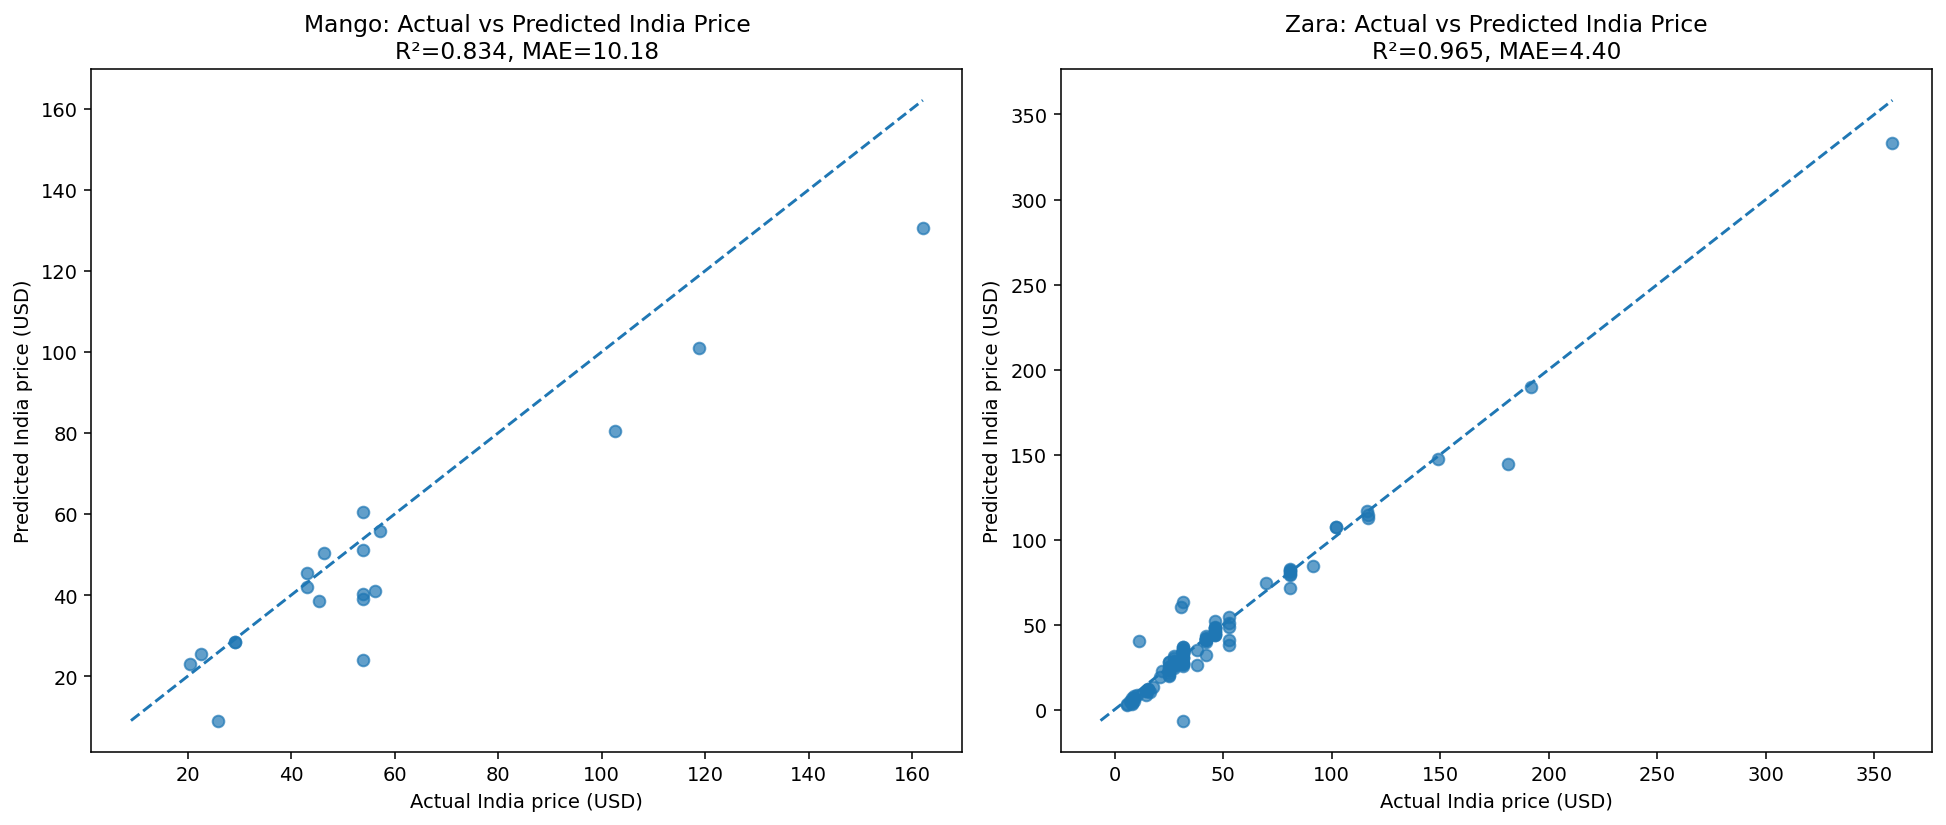

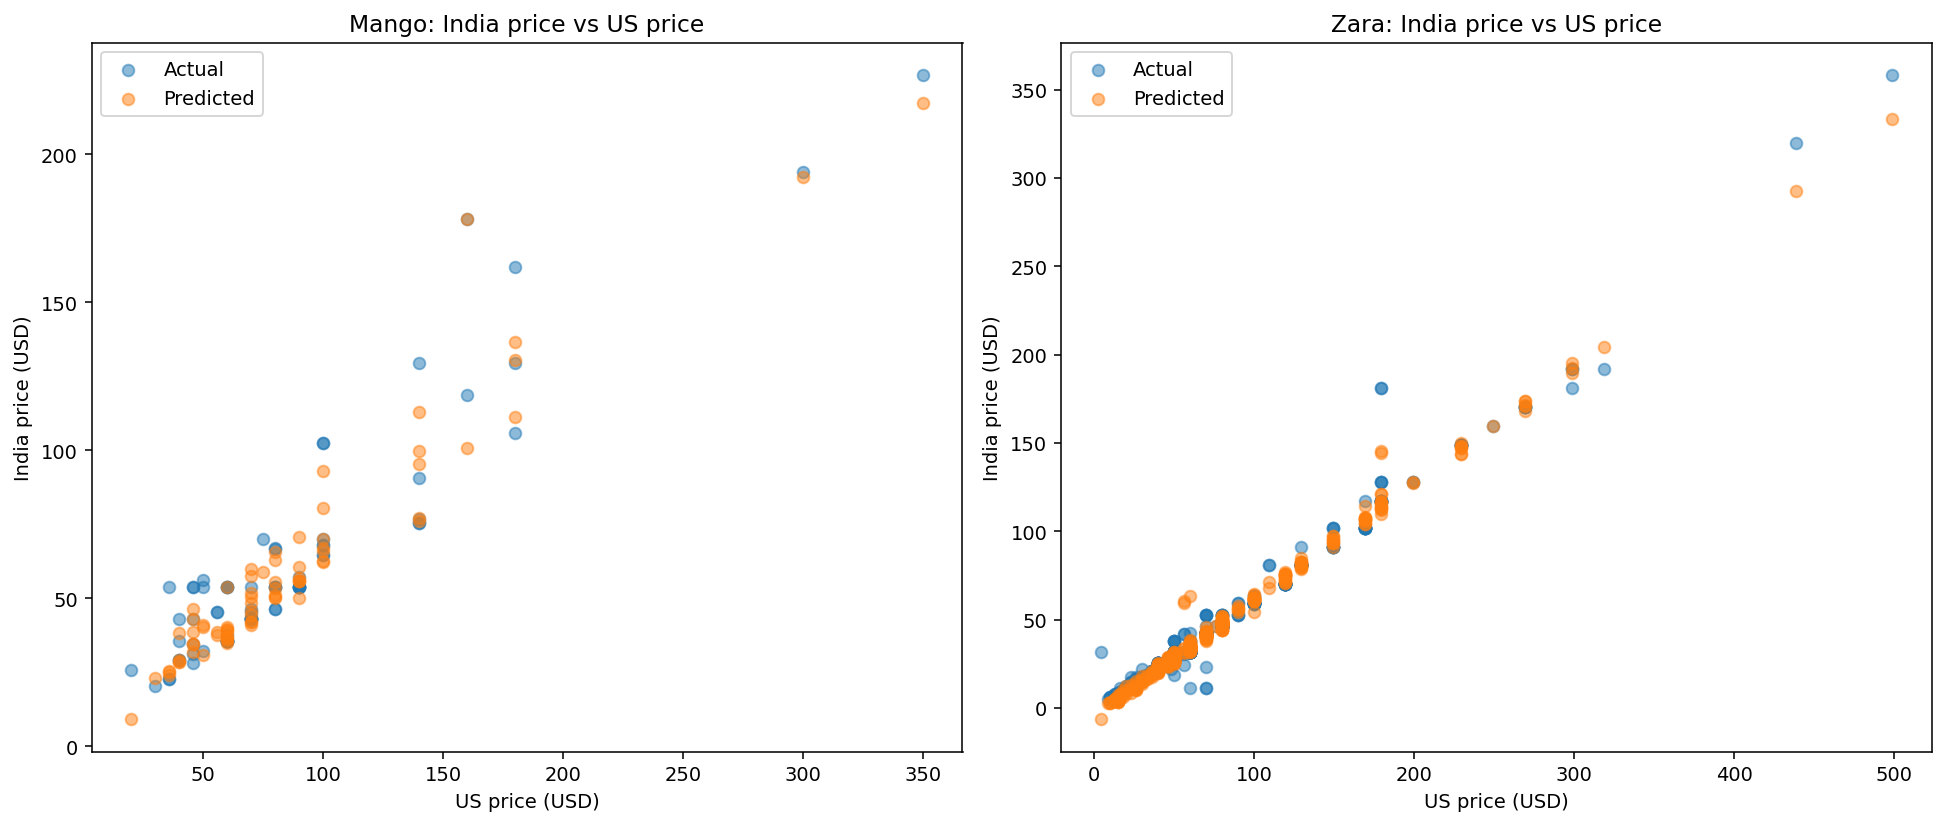

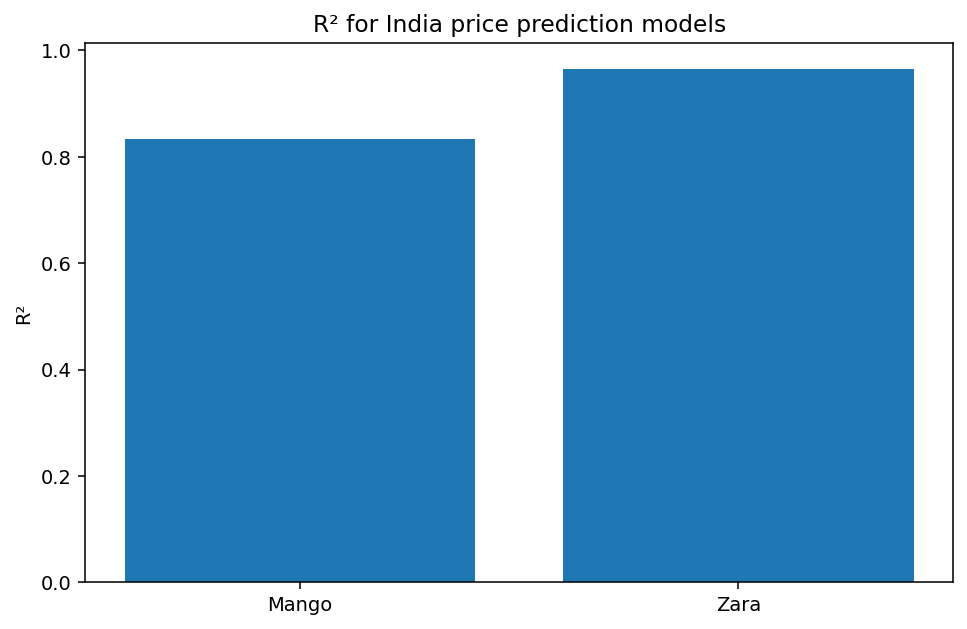

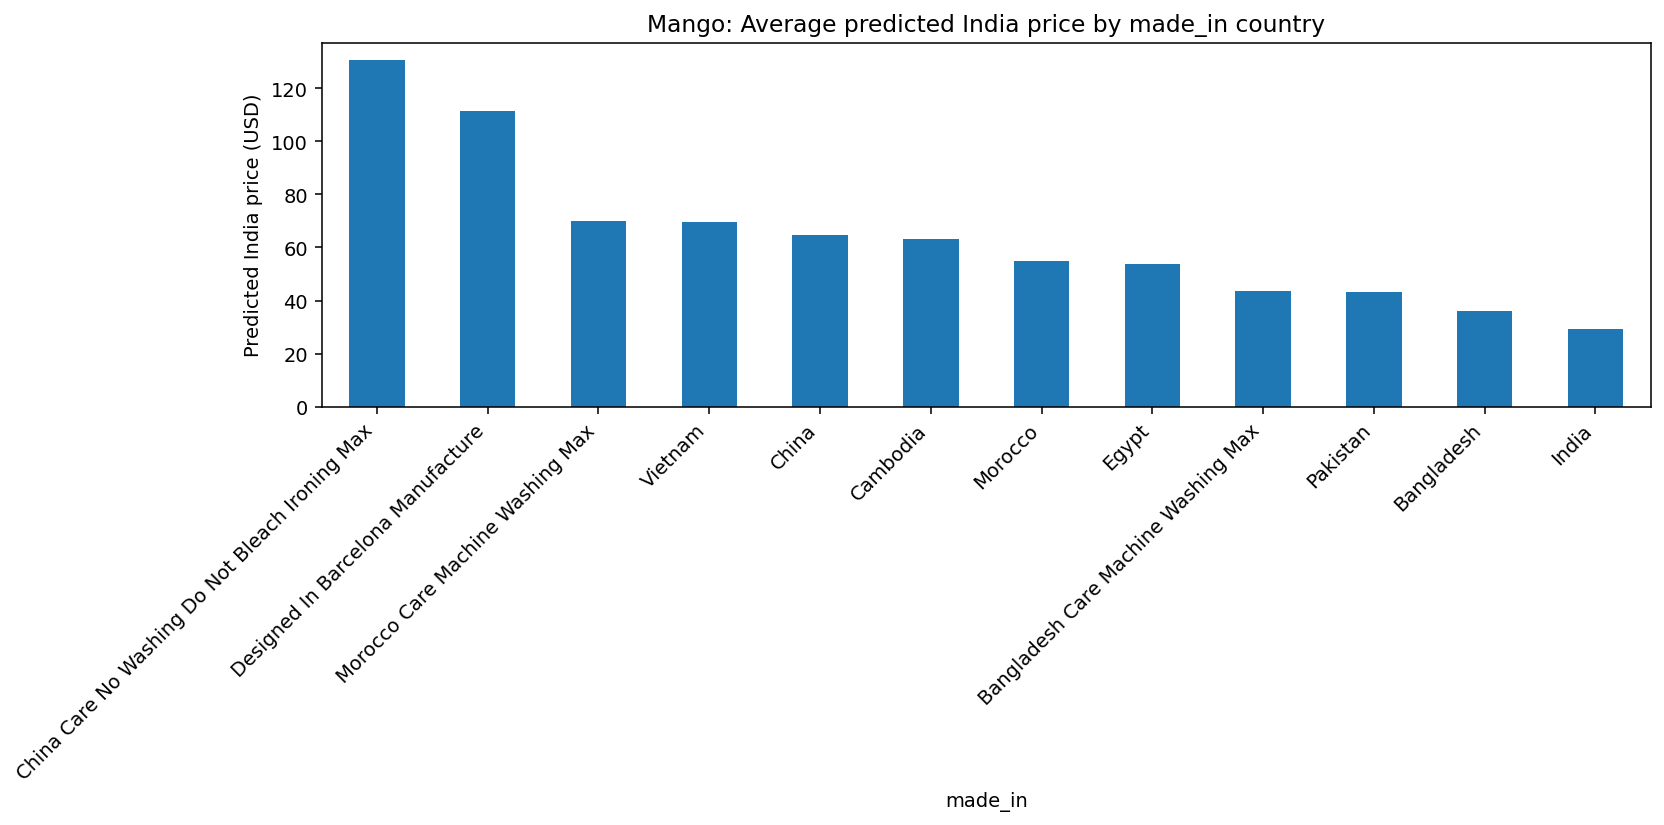

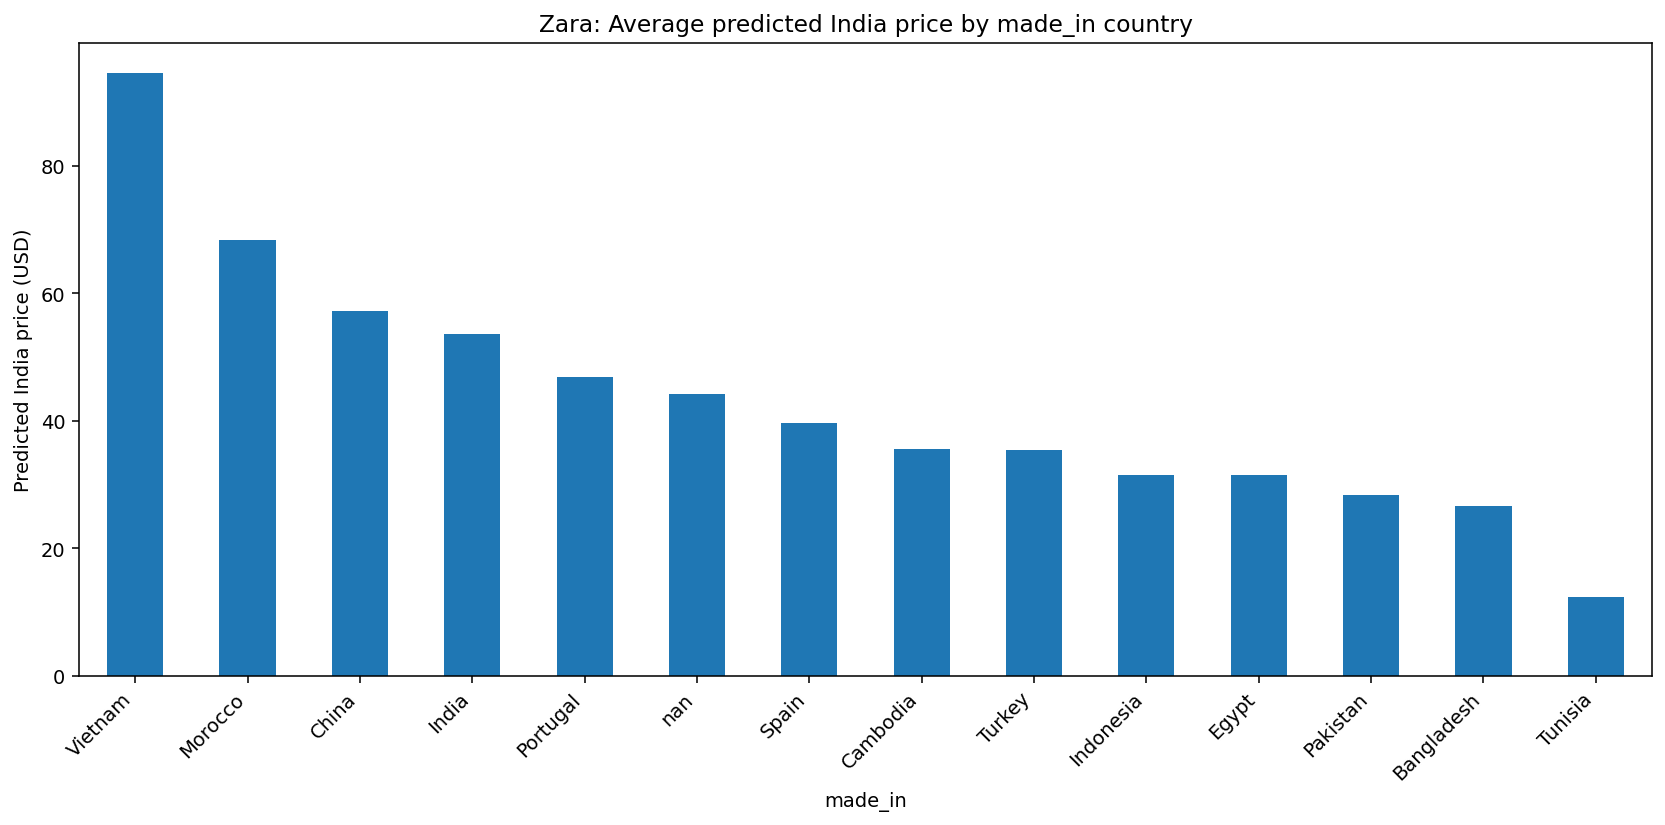

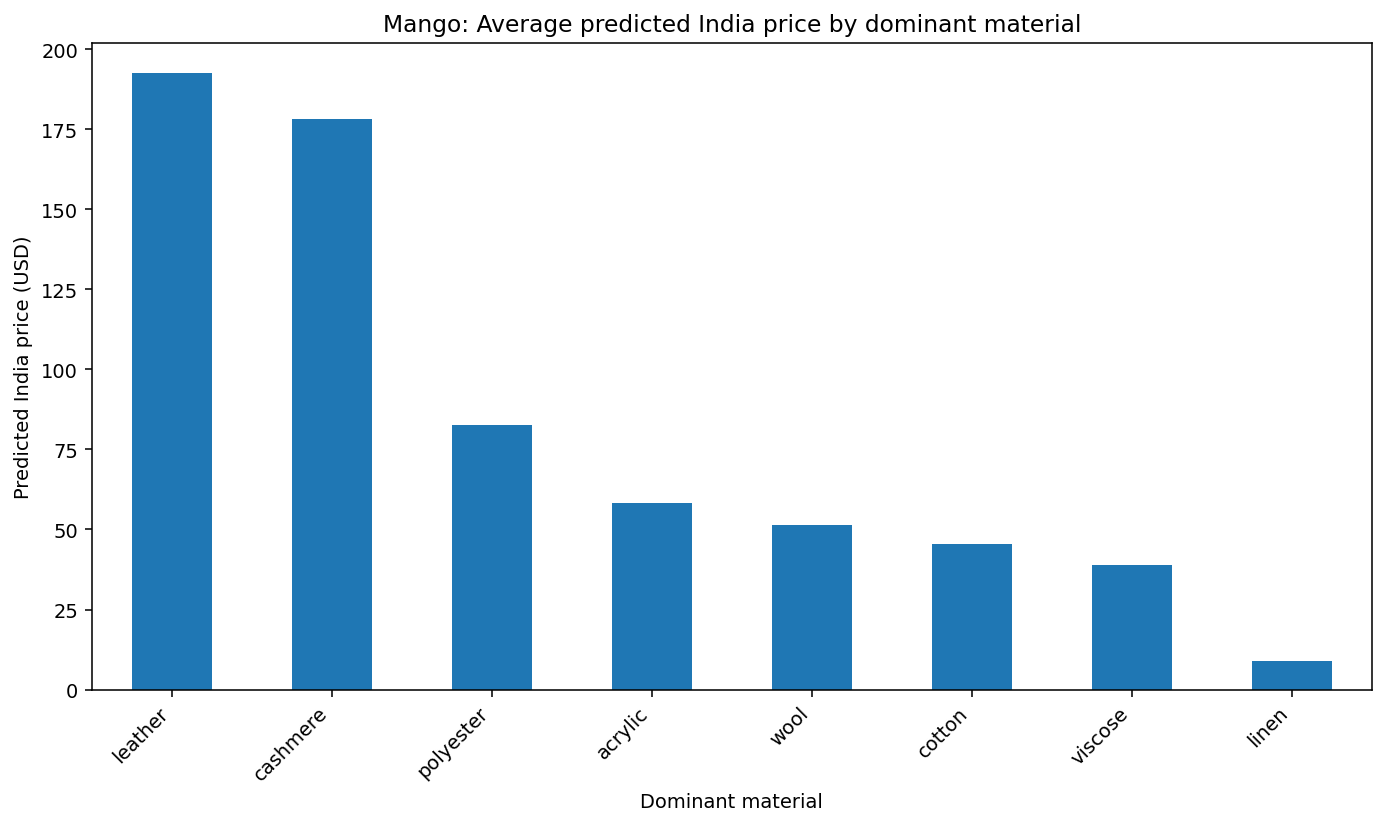

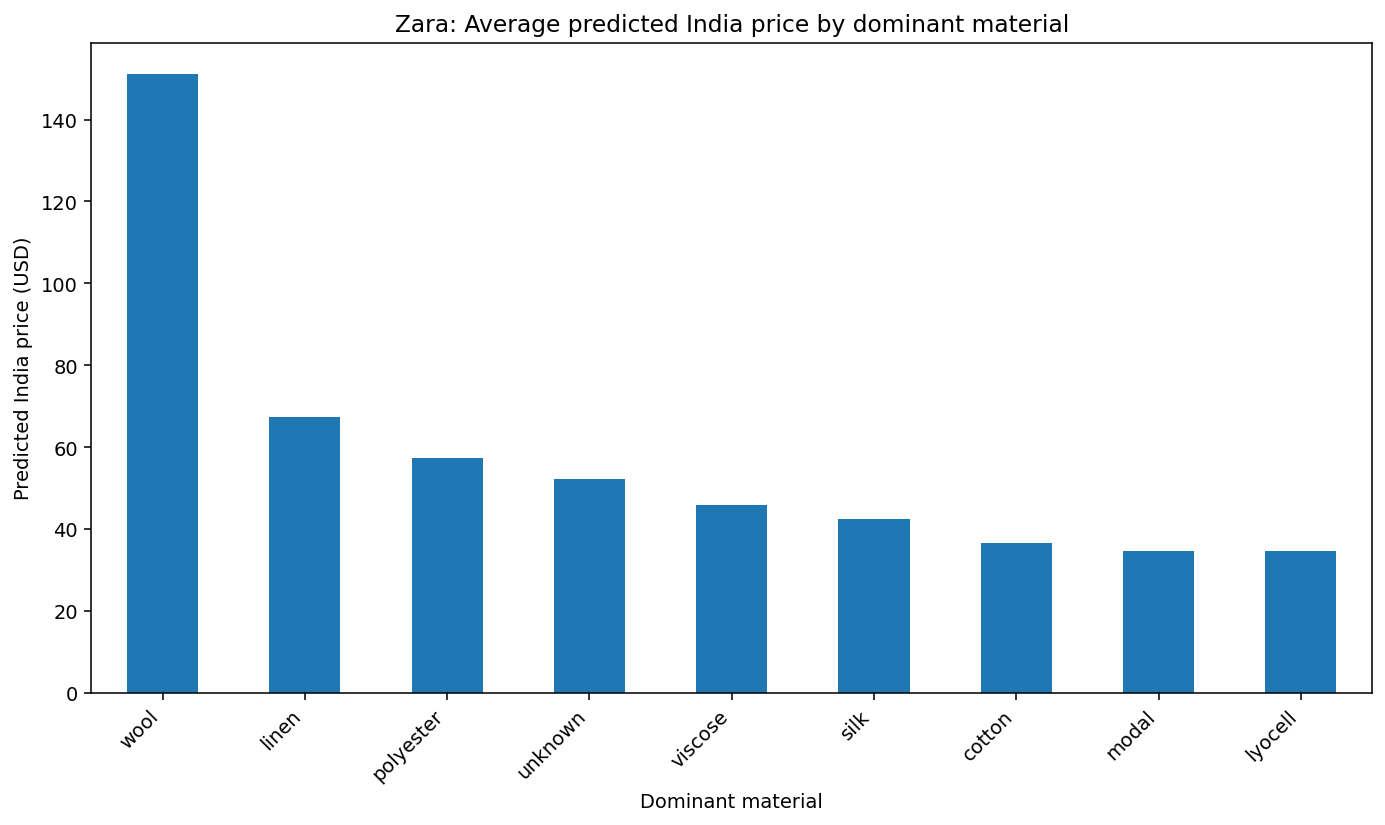

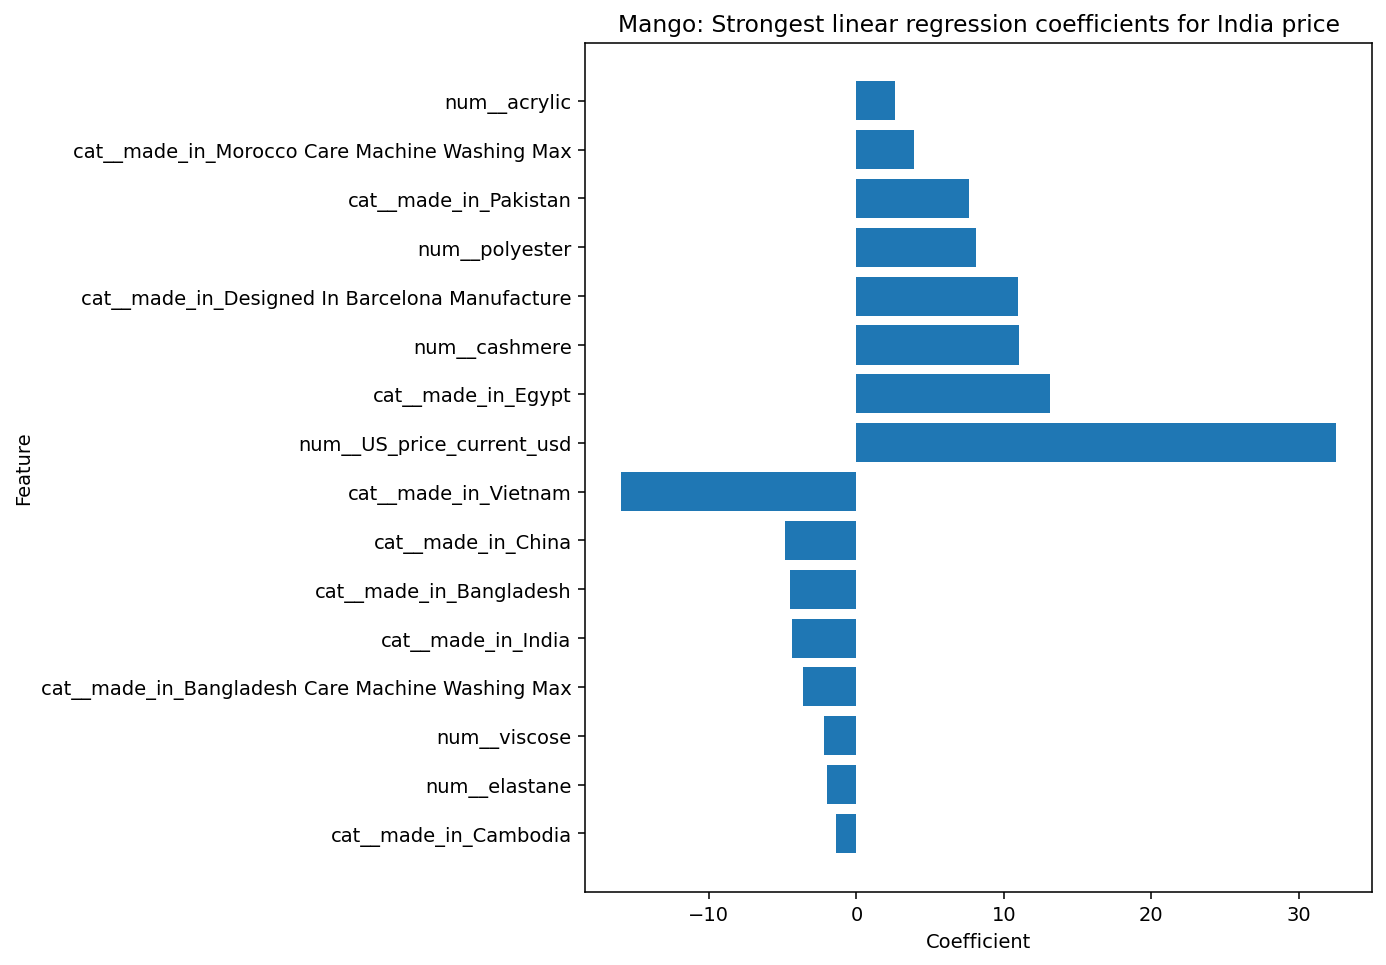

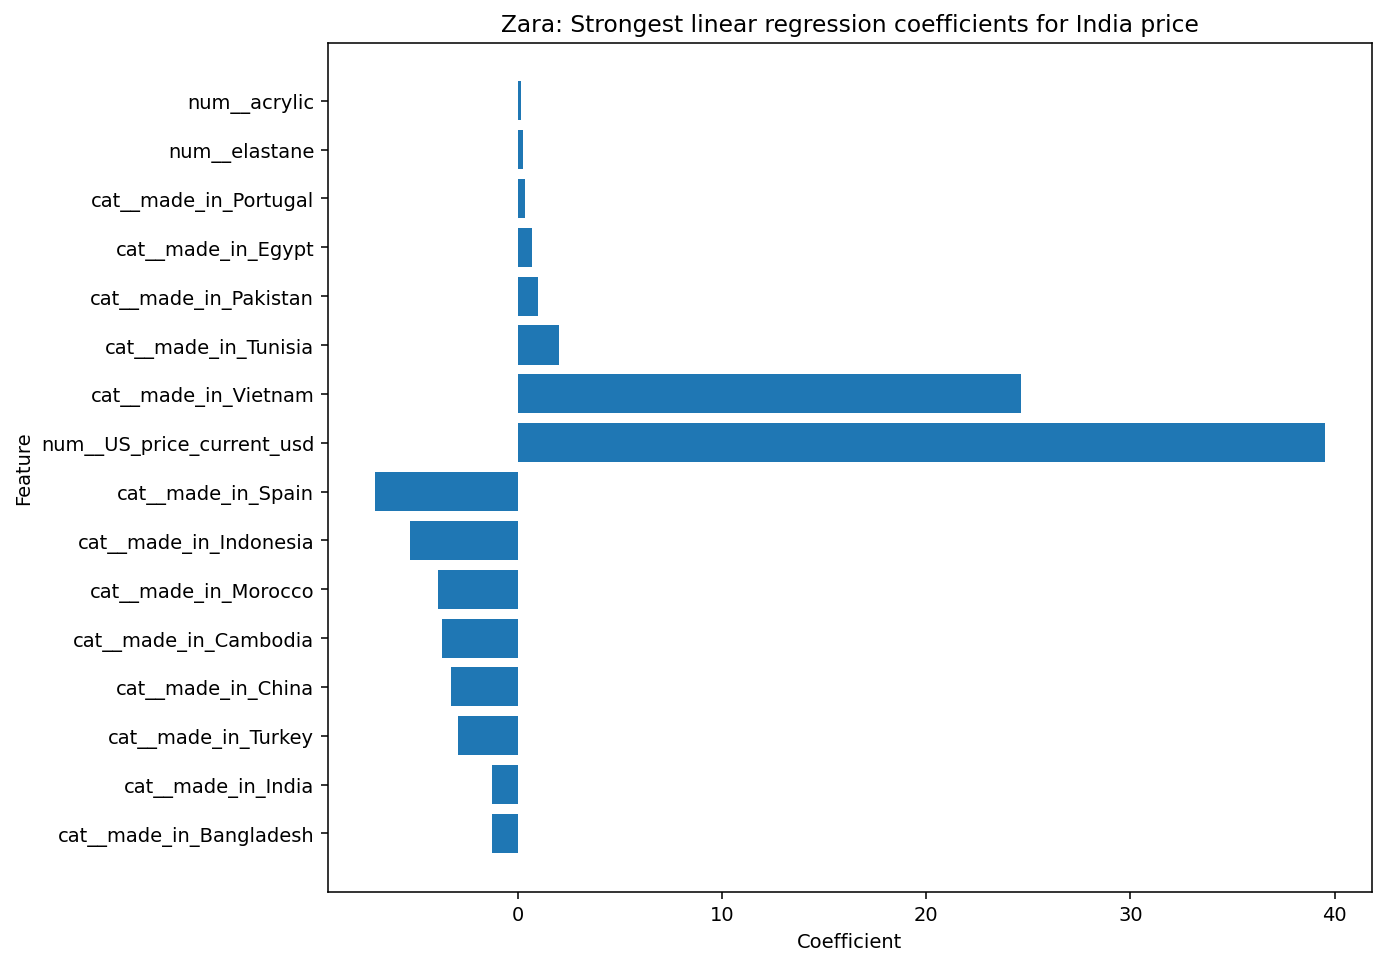


Saved files to /content:
- india_price_prediction_metrics.csv
- mango_india_predictions_with_us_metric.csv
- zara_india_predictions_with_us_metric.csv
- mango_india_coefficients_with_us_metric.csv
- zara_india_coefficients_with_us_metric.csv


In [18]:
# ============================================================
# LINEAR REGRESSION
# Predict INDIA price only
# Uses:
#   - US_price_current_usd  <- predictor
#   - materials_text        <- predictor
#   - made_in               <- predictor
# Target:
#   - IN_price_current_usd
# Runs separate models for Mango and Zara
# Auto-detects CSVs in /content
# ============================================================

import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# ---------- Auto-detect files ----------
all_files = os.listdir("/content")
csv_files = [f for f in all_files if f.lower().endswith(".csv")]

print("CSV files found in /content:")
for f in csv_files:
    print(" -", f)

mango_candidates = [f for f in csv_files if "mango" in f.lower()]
zara_candidates  = [f for f in csv_files if "zara" in f.lower()]

if len(mango_candidates) == 0:
    raise FileNotFoundError("No Mango CSV found in /content.")
if len(zara_candidates) == 0:
    raise FileNotFoundError("No Zara CSV found in /content.")

MANGO_FILE = os.path.join("/content", mango_candidates[0])
ZARA_FILE  = os.path.join("/content", zara_candidates[0])

print("\nUsing files:")
print("Mango:", MANGO_FILE)
print("Zara :", ZARA_FILE)

# ---------- Load only needed columns ----------
keep_cols = [
    "materials_text",
    "made_in",
    "US_price_current_usd",
    "IN_price_current_usd"
]

mango = pd.read_csv(MANGO_FILE)
zara = pd.read_csv(ZARA_FILE)

missing_mango = [c for c in keep_cols if c not in mango.columns]
missing_zara  = [c for c in keep_cols if c not in zara.columns]

if missing_mango:
    raise ValueError(f"Mango file is missing columns: {missing_mango}")
if missing_zara:
    raise ValueError(f"Zara file is missing columns: {missing_zara}")

mango = mango[keep_cols].copy()
zara = zara[keep_cols].copy()

mango["Brand"] = "Mango"
zara["Brand"] = "Zara"

df = pd.concat([mango, zara], ignore_index=True)

print("\nCombined shape:", df.shape)
print("\nColumns used:", df.columns.tolist())

# ---------- Clean text fields ----------
def clean_made_in(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace("\n", " ").strip()
    x = re.sub(r"\s+", " ", x)
    x = x.replace("Made in ", "").replace("made in ", "")
    x = x.strip(" -|:,")
    if x == "":
        return np.nan
    return x.title()

df["made_in"] = df["made_in"].apply(clean_made_in)
df["materials_text"] = df["materials_text"].fillna("").astype(str)

# ---------- Build numeric material features ----------
MATERIALS = [
    "cotton", "polyester", "linen", "elastane", "viscose", "wool",
    "polyamide", "lyocell", "modal", "acrylic", "silk", "cashmere",
    "leather", "ramie", "hemp"
]

def parse_material_percentages(text):
    text = str(text).lower()
    out = {m: 0.0 for m in MATERIALS}

    # Match patterns like "70% cotton"
    matches = re.findall(r'(\d+(?:\.\d+)?)\s*%\s*([a-zA-Z ]+?)(?=,|\||$)', text)

    for pct, mat in matches:
        pct = float(pct)
        mat = mat.strip()
        for m in MATERIALS:
            if m in mat:
                out[m] += pct

    # If no % found, use binary presence
    for m in MATERIALS:
        if out[m] == 0 and m in text:
            out[m] = 1.0

    return out

material_df = pd.DataFrame(df["materials_text"].apply(parse_material_percentages).tolist())
df = pd.concat([df.reset_index(drop=True), material_df.reset_index(drop=True)], axis=1)

df["dominant_material"] = material_df.idxmax(axis=1)
df.loc[material_df.max(axis=1) == 0, "dominant_material"] = "unknown"

# ---------- Model function ----------
def fit_india_price_model(data, brand_name):
    sub = data[
        (data["Brand"] == brand_name) &
        (data["IN_price_current_usd"].notna()) &
        (data["US_price_current_usd"].notna())
    ].copy()

    if len(sub) < 8:
        print(f"Not enough rows for {brand_name}")
        return None

    feature_cols_num = ["US_price_current_usd"] + MATERIALS
    feature_cols_cat = ["made_in"]

    X = sub[feature_cols_num + feature_cols_cat].copy()
    y = sub["IN_price_current_usd"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler", StandardScaler())
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, feature_cols_num),
        ("cat", categorical_pipe, feature_cols_cat)
    ])

    model = Pipeline([
        ("prep", preprocessor),
        ("lr", LinearRegression())
    ])

    model.fit(X_train, y_train)
    pred_test = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred_test)
    r2 = r2_score(y_test, pred_test)

    sub["predicted_india_price"] = model.predict(X)
    sub["actual_minus_predicted"] = sub["IN_price_current_usd"] - sub["predicted_india_price"]

    feature_names = model.named_steps["prep"].get_feature_names_out()
    coefs = model.named_steps["lr"].coef_

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs
    }).sort_values("coefficient", ascending=False)

    return {
        "brand": brand_name,
        "data": sub,
        "model": model,
        "coef_df": coef_df,
        "mae": mae,
        "r2": r2,
        "y_test": y_test,
        "pred_test": pred_test
    }

# ---------- Fit models ----------
results = {
    "Mango": fit_india_price_model(df, "Mango"),
    "Zara": fit_india_price_model(df, "Zara")
}

# ---------- Metrics ----------
metrics_rows = []
for brand, res in results.items():
    if res is not None:
        metrics_rows.append({
            "Brand": brand,
            "Rows Used": len(res["data"]),
            "MAE": round(res["mae"], 3),
            "R2": round(res["r2"], 3)
        })

metrics_df = pd.DataFrame(metrics_rows).sort_values("Brand")
print("\nIndia price model metrics")
print(metrics_df)

# ---------- Graph 1: Actual vs Predicted India price ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, brand in zip(axes, ["Mango", "Zara"]):
    res = results[brand]
    if res is None:
        ax.set_title(f"{brand}\nNot enough data")
        ax.axis("off")
        continue

    y_true = res["y_test"]
    y_pred = res["pred_test"]

    ax.scatter(y_true, y_pred, alpha=0.7)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], linestyle="--")

    ax.set_title(f"{brand}: Actual vs Predicted India Price\nR²={res['r2']:.3f}, MAE={res['mae']:.2f}")
    ax.set_xlabel("Actual India price (USD)")
    ax.set_ylabel("Predicted India price (USD)")

plt.tight_layout()
plt.show()

# ---------- Graph 2: India price vs US price ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, brand in zip(axes, ["Mango", "Zara"]):
    res = results[brand]
    if res is None:
        ax.set_title(f"{brand}\nNot enough data")
        ax.axis("off")
        continue

    plot_df = res["data"].copy()

    ax.scatter(plot_df["US_price_current_usd"], plot_df["IN_price_current_usd"], alpha=0.5, label="Actual")
    ax.scatter(plot_df["US_price_current_usd"], plot_df["predicted_india_price"], alpha=0.5, label="Predicted")
    ax.set_title(f"{brand}: India price vs US price")
    ax.set_xlabel("US price (USD)")
    ax.set_ylabel("India price (USD)")
    ax.legend()

plt.tight_layout()
plt.show()

# ---------- Graph 3: R² comparison ----------
if not metrics_df.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(metrics_df["Brand"], metrics_df["R2"])
    plt.title("R² for India price prediction models")
    plt.ylabel("R²")
    plt.show()

# ---------- Graph 4: Predicted India price by made_in country ----------
for brand in ["Mango", "Zara"]:
    res = results[brand]
    if res is None:
        continue

    country_pred = (
        res["data"]
        .groupby("made_in", dropna=False)["predicted_india_price"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 6))
    country_pred.plot(kind="bar")
    plt.title(f"{brand}: Average predicted India price by made_in country")
    plt.ylabel("Predicted India price (USD)")
    plt.xlabel("made_in")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# ---------- Graph 5: Predicted India price by dominant material ----------
for brand in ["Mango", "Zara"]:
    res = results[brand]
    if res is None:
        continue

    material_pred = (
        res["data"]
        .groupby("dominant_material")["predicted_india_price"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))
    material_pred.plot(kind="bar")
    plt.title(f"{brand}: Average predicted India price by dominant material")
    plt.ylabel("Predicted India price (USD)")
    plt.xlabel("Dominant material")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# ---------- Graph 6: Strongest coefficients ----------
for brand in ["Mango", "Zara"]:
    res = results[brand]
    if res is None:
        continue

    coef_df = res["coef_df"].copy()
    top_pos = coef_df.head(8)
    top_neg = coef_df.tail(8)
    show_df = pd.concat([top_neg, top_pos])

    plt.figure(figsize=(10, 7))
    plt.barh(show_df["feature"], show_df["coefficient"])
    plt.title(f"{brand}: Strongest linear regression coefficients for India price")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# ---------- Save outputs ----------
metrics_df.to_csv("/content/india_price_prediction_metrics.csv", index=False)

for brand, res in results.items():
    if res is None:
        continue
    brand_lower = brand.lower()
    res["data"].to_csv(f"/content/{brand_lower}_india_predictions_with_us_metric.csv", index=False)
    res["coef_df"].to_csv(f"/content/{brand_lower}_india_coefficients_with_us_metric.csv", index=False)

print("\nSaved files to /content:")
print("- india_price_prediction_metrics.csv")
print("- mango_india_predictions_with_us_metric.csv")
print("- zara_india_predictions_with_us_metric.csv")
print("- mango_india_coefficients_with_us_metric.csv")
print("- zara_india_coefficients_with_us_metric.csv")